<a href="https://colab.research.google.com/github/alokanandasengupta/rumik_/blob/main/Rumik_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The Business Question

**In one sentence:** The second someone signs up for IRA — before they've sent
even one message — can we guess how valuable they'll be?

**We're guessing 3 things:**
1. Will they ever pay us? *(a Yes/No question)*
2. How long will they stick around? *(a "how long" question)*
3. How much money will they bring in? *(a rupee-amount question)*

---

### Why "before they message" is the hard part

Imagine judging whether a stranger will become your friend — using only
what they were wearing when they walked in the door. That's the challenge.
Once they start talking, guessing is easy. We're forced to guess *before* that.

---

### Why this is secretly 3 different puzzles, not 1

- **Puzzle 1 (Will they pay?)** → a Yes/No puzzle.
- **Puzzle 2 (How long will they stay?)** → trickier. Think of a room full
  of candles burning. Some have burned out — you know exactly how long they
  lasted. Others are *still burning right now* — you don't get to know their
  final length yet. We have to handle both kinds honestly, not pretend the
  still-burning ones already went out.
- **Puzzle 3 (How much will they spend?)** → weird, because 95 out of 100
  people spend ₹0. The "average" is mostly zeros with a few big spenders
  dragging it up. A normal average lies to you here.

---

### 3 traps to watch for

- **Trap 1:** Only ~5 in 100 people ever pay. A model that says "nobody
  pays" is right 95% of the time — and useless. So "% correct" is the
  wrong scorecard for us.
- **Trap 2:** A few people even pay *before* sending their first message.
  "Before the first message" isn't as clean a line as it sounds.
- **Trap 3:** Where someone came from (which ad) matters — but some ads
  get "credit" for people who would've signed up anyway. We have to be
  careful not to be fooled by that.

---

### What "done" looks like

Not a perfect model. A model good enough that if we used it to decide
"who gets extra attention right after signup," we'd make better calls
than just guessing randomly.

**Load the file**

In [12]:
import pandas as pd

FILE = "/content/drive/MyDrive/IRA_Rumik_Synthetic_Product_Analytics_6mo_50K (1).xlsx"

xl = pd.ExcelFile(FILE)

print(xl.sheet_names)

['README_data_dictionary', 'README_known_data_issues', 'README_gap_fix_log', 'dim_users', 'fact_events', 'fact_payments', 'subscription_lifecycle', 'experiment_rollout_calendar', 'marketing_spend_weekly', 'creative_performance_weekly', 'ad_dayparting_hourly', 'incrementality_test_log', 'audience_overlap_estimates', 'nudge_log', 'support_tickets', 'user_happiness_snapshots']


**Do the Primary ID's actually connect?**

In [14]:
dim_users = pd.read_excel(FILE, sheet_name='dim_users')
fact_events = pd.read_excel(FILE, sheet_name='fact_events')
subscription_lifecycle = pd.read_excel(FILE, sheet_name='subscription_lifecycle')

print("dim_users:", dim_users.shape)
print("fact_events:", fact_events.shape)
print("subscription_lifecycle:", subscription_lifecycle.shape)

dim_users: (50000, 25)
fact_events: (721270, 28)
subscription_lifecycle: (6498, 11)


**Is missing data explainable?**

This cell doesn't just count the blanks, it checks who has them, so we can tell "blank because it doesn't apply" apart from "blank because something's broken."

In [15]:
null_check = dim_users[['platform','media_source','ad_set_id','device_model','ad_intent','targeting_interest']].isna().mean().round(3)
print(null_check)

# trace WHY ad_set_id is null -- should be exactly the organic/referral (unpaid) channels
print(dim_users.groupby('channel')['ad_set_id'].apply(lambda s: s.isna().mean()).round(3))

platform              0.000
media_source          0.000
ad_set_id             0.428
device_model          0.031
ad_intent             0.338
targeting_interest    0.428
dtype: float64
channel
Google Ads               0.0
Instagram Influencers    0.0
Meta Ads                 0.0
Organic App Store        1.0
User Invite              1.0
YouTube Creators         0.0
Name: ad_set_id, dtype: float64


**Known quirks still present?**

This dataset was built to mimic a real, slightly messy production system on purpose, some duplicate log entries, and one event ("someone subscribed") accidentally logged under three different names

In [16]:
dup_check = fact_events['insert_id'].value_counts()
print("duplicate insert_ids:", (dup_check > 1).sum(), "(expect ~432)")

comp_split = fact_events[fact_events.event_name.isin(
    ['Subscription Purchase Completed','Subscription Purchased','purchase'])]['event_name'].value_counts()
print(comp_split)

# confirm the two gap-fix additions actually made it into this file
print("App Opened events present:", (fact_events.event_name == 'App Opened').sum())
print("message_content_category populated on Message Sent rows:",
      fact_events[fact_events.event_name=='Message Sent']['message_content_category'].notna().mean())

duplicate insert_ids: 432 (expect ~432)
event_name
Subscription Purchase Completed    1877
Subscription Purchased              509
purchase                            211
Name: count, dtype: int64
App Opened events present: 110014
message_content_category populated on Message Sent rows: 1.0


**Do the big numbers match expectations?**

In [17]:
activation_rate = fact_events[fact_events.event_name=='Message Sent'].user_id.nunique() / len(dim_users)
payer_rate = dim_users.is_paid_user_current.mean()

print(f"Activation rate: {activation_rate:.4f}  (expect ~0.7997)")
print(f"Payer rate:      {payer_rate:.4f}  (expect ~0.0519)")

print(f"\nsignup range: {dim_users.signup_ts.min()} -> {dim_users.signup_ts.max()}")
print(f"event range:  {fact_events.event_ts.min()} -> {fact_events.event_ts.max()}")

Activation rate: 0.7997  (expect ~0.7997)
Payer rate:      0.0519  (expect ~0.0519)

signup range: 2026-01-01 01:48:22.469000 -> 2026-06-30 21:58:24.896000
event range:  2026-01-01 01:48:22.469000 -> 2026-07-09 23:59:34.684000


**Draw the "before you messaged" line**

For every user, we're writing down two moments in time: the very first thing they ever did in the app (even just opening it), and the moment they sent their first message. This gives us a clean line in the sand, "everything before this line is fair game to use for predicting; everything after is off-limits, because that's basically peeking at the answer."

In [18]:
# Anything except the signup event itself counts as an "interaction"
non_signup = fact_events[fact_events.event_name != 'User Signed Up']
first_interaction = non_signup.groupby('user_id')['event_ts'].min().rename('first_interaction_ts')

# Activation is specifically defined by messaging, not just opening the app
msg_events = fact_events[fact_events.event_name.isin(['Message Sent', 'Message Received'])]
first_message = msg_events.groupby('user_id')['event_ts'].min().rename('first_message_ts')

bridge_first_interaction = (
    dim_users[['user_id', 'signup_ts']]
    .merge(first_message, on='user_id', how='left')
    .merge(first_interaction, on='user_id', how='left')
)

bridge_first_interaction['activation_flag'] = bridge_first_interaction['first_message_ts'].notna()
bridge_first_interaction['has_any_interaction_flag'] = bridge_first_interaction['first_interaction_ts'].notna()
bridge_first_interaction['browse_to_chat_latency_minutes'] = (
    (bridge_first_interaction['first_message_ts'] - bridge_first_interaction['first_interaction_ts'])
    .dt.total_seconds() / 60
)

print(bridge_first_interaction.shape)
bridge_first_interaction.head()


(50000, 7)


,user_id,signup_ts,first_message_ts,first_interaction_ts,activation_flag,has_any_interaction_flag,browse_to_chat_latency_minutes
0,usr_0000001,2026-01-24 13:22:37.078,NaT,NaT,False,False,NaN
1,usr_0000002,2026-01-14 09:13:40.916,2026-01-14 09:34:58.570,2026-01-14 09:28:50.173,True,True,6.139950
2,usr_0000003,2026-01-27 06:40:42.808,2026-01-27 07:04:59.641,2026-01-27 06:54:05.344,True,True,10.904950
3,usr_0000004,2026-01-22 14:00:53.931,2026-01-22 17:01:38.305,2026-01-22 16:50:32.912,True,True,11.089883
4,usr_0000005,2026-01-04 02:04:53.686,2026-01-04 05:45:26.339,2026-01-04 05:11:36.694,True,True,33.827417


**Prove the line actually holds**

Someone's "first thing ever" appearing after their first message would mean our clock is broken. It must show zero violations, or nothing built afterward can be trusted.

In [19]:
activated = bridge_first_interaction[bridge_first_interaction.activation_flag]

# THE critical check: first interaction must never come AFTER first message
violations = activated[activated.first_interaction_ts > activated.first_message_ts]
print("boundary violations (must be 0):", len(violations))

same_moment_pct = (activated.first_interaction_ts == activated.first_message_ts).mean()
print(f"first interaction IS the first message (no earlier touch): {same_moment_pct:.4f}")
print(f"median browse-to-chat latency: {activated.browse_to_chat_latency_minutes.median():.2f} minutes")

never_any_signal = (~bridge_first_interaction.has_any_interaction_flag).sum()
opened_never_messaged = (bridge_first_interaction.has_any_interaction_flag & ~bridge_first_interaction.activation_flag).sum()
print(f"\nusers with zero signal ever (fully dark): {never_any_signal}")
print(f"users who engaged but never sent a message: {opened_never_messaged}")

boundary violations (must be 0): 0
first interaction IS the first message (no earlier touch): 0.0000
median browse-to-chat latency: 8.58 minutes

users with zero signal ever (fully dark): 6721
users who engaged but never sent a message: 3296


**What's the very first thing people actually do?**

Out of curiosity — and to sanity-check the line we drew — this cell asks "what's the actual first action people take?" Mostly it should be "opened the app," with a tiny handful of people whose very first action is looking at subscription plans before ever chatting

In [20]:
# Join back to find out which event fired at each user's first_interaction_ts
first_touch = non_signup.merge(
    first_interaction.reset_index(), on='user_id'
)
first_touch = first_touch[first_touch.event_ts == first_touch.first_interaction_ts]

print(first_touch.event_name.value_counts())

event_name
App Opened                   43262
Subscription Plans Viewed       43
Name: count, dtype: int64


**Has enough time passed to know the answer?**

This cell finds everyone who signed up too recently to have had a fair 30-day shot yet, and tags them "not gradeable" so we never accidentally mark a "hasn't paid yet" person as a confirmed "will never pay."

In [21]:
EVENT_END = pd.Timestamp('2026-07-09 23:59:59')

label_table = dim_users[['user_id', 'signup_ts']].copy()
label_table['days_observed'] = ((EVENT_END - label_table['signup_ts']).dt.total_seconds() / 86400).clip(upper=30)
label_table['label_mature_d30'] = label_table['days_observed'] >= 30

print(f"Mature (full 30-day window observed): {label_table['label_mature_d30'].mean():.4f}")
print(f"Immature (D30 label not yet knowable): {(~label_table['label_mature_d30']).mean():.4f}")
print(f"\nEarliest immature signup: {label_table[~label_table.label_mature_d30].signup_ts.min()}")

Mature (full 30-day window observed): 0.8389
Immature (D30 label not yet knowable): 0.1611

Earliest immature signup: 2026-06-10 00:00:29.558000


**How much money did each person actually bring in?**



In [22]:
d30_cutoff = label_table.set_index('user_id')['signup_ts'] + pd.Timedelta(days=30)

# Subscription revenue -- the trustworthy ledger, now that it carries amount_inr directly
sub_rev = subscription_lifecycle[subscription_lifecycle.event_name.isin(['Subscription Purchased', 'Subscription Renewed'])].copy()
sub_rev['cutoff'] = sub_rev['user_id'].map(d30_cutoff)
sub_rev_d30 = sub_rev[sub_rev.event_ts <= sub_rev.cutoff]

# Credit pack revenue -- only exists in fact_events, easy to forget
pack_rev = fact_events[fact_events.event_name == 'Credit Pack Purchase Completed'].copy()
pack_rev['cutoff'] = pack_rev['user_id'].map(d30_cutoff)
pack_rev_d30 = pack_rev[pack_rev.event_ts <= pack_rev.cutoff]

sub_ltv = sub_rev_d30.groupby('user_id')['amount_inr'].sum().rename('sub_ltv_d30')
pack_ltv = pack_rev_d30.groupby('user_id')['amount_inr'].sum().rename('pack_ltv_d30')

label_table = label_table.merge(sub_ltv, on='user_id', how='left').merge(pack_ltv, on='user_id', how='left')
label_table[['sub_ltv_d30', 'pack_ltv_d30']] = label_table[['sub_ltv_d30', 'pack_ltv_d30']].fillna(0)
label_table['ltv_d30'] = label_table['sub_ltv_d30'] + label_table['pack_ltv_d30']
label_table['is_payer_d30'] = label_table['ltv_d30'] > 0

print(f"Payer rate among MATURE users: {label_table[label_table.label_mature_d30].is_payer_d30.mean():.4f}")
print(f"Payer rate among IMMATURE users: {label_table[~label_table.label_mature_d30].is_payer_d30.mean():.4f}")
print(f"\n% of LTV coming from credit packs alone: {label_table.pack_ltv_d30.sum() / label_table.ltv_d30.sum():.4f}")

Payer rate among MATURE users: 0.1065
Payer rate among IMMATURE users: 0.1039

% of LTV coming from credit packs alone: 0.6481


**How long did people actually stick around?**

In [23]:
last_activity = fact_events[fact_events.event_name != 'User Signed Up'].groupby('user_id')['event_ts'].max().rename('last_event_ts')
label_table = label_table.merge(last_activity, on='user_id', how='left')

signup_map = dim_users.set_index('user_id')['signup_ts']
label_table['last_active_offset_days'] = (
    (label_table['last_event_ts'] - label_table['user_id'].map(signup_map)).dt.total_seconds() / 86400
).clip(lower=0)

# right-censoring signal: last known activity sits within 2 days of the edge of what we've observed
label_table['still_active_at_censor'] = (
    label_table['days_observed'] - label_table['last_active_offset_days']
) <= 2

print(f"Median last-active offset (days): {label_table.last_active_offset_days.median():.2f}")
print(f"% flagged still-active-at-censor: {label_table.still_active_at_censor.mean():.4f}")
print(f"  -- of which mature: {label_table[label_table.still_active_at_censor].label_mature_d30.mean():.4f}")

Median last-active offset (days): 1.92
% flagged still-active-at-censor: 0.0617
  -- of which mature: 0.9553


In [24]:
print(label_table.shape)
print(label_table[['days_observed','label_mature_d30','ltv_d30','is_payer_d30','last_active_offset_days','still_active_at_censor']].describe(include='all'))

(50000, 11)
        days_observed label_mature_d30       ltv_d30 is_payer_d30  \
count    50000.000000            50000  50000.000000        50000   
unique            NaN                2           NaN            2   
top               NaN             True           NaN        False   
freq              NaN            41947           NaN        44694   
mean        28.354323              NaN     45.551660          NaN   
std          4.443586              NaN    165.238162          NaN   
min          9.084423              NaN      0.000000          NaN   
25%         30.000000              NaN      0.000000          NaN   
50%         30.000000              NaN      0.000000          NaN   
75%         30.000000              NaN      0.000000          NaN   
max         30.000000              NaN   1798.000000          NaN   

        last_active_offset_days still_active_at_censor  
count              43279.000000                  50000  
unique                      NaN              

**Split "payer" into two honest definitions**

Payer" turned out to mean two different things, ever subscribed" (~5%) versus ever paid anything at all, including credit packs.

In [25]:
label_table['is_payer_d30_subscription_only'] = label_table['sub_ltv_d30'] > 0
label_table['is_payer_d30_any_revenue'] = label_table['ltv_d30'] > 0
label_table.drop(columns=['is_payer_d30'], inplace=True)  # ambiguous name retired in favor of the two explicit ones

print("Subscription-only payer rate:", f"{label_table.is_payer_d30_subscription_only.mean():.4f}")
print("Any-revenue payer rate:      ", f"{label_table.is_payer_d30_any_revenue.mean():.4f}")
print("Credit-pack-only payers (any-revenue but NOT subscription):",
      f"{(label_table.is_payer_d30_any_revenue & ~label_table.is_payer_d30_subscription_only).mean():.4f}")

print("\nFinal label_table columns:")
print(label_table.columns.tolist())
print(label_table.shape)

Subscription-only payer rate: 0.0519
Any-revenue payer rate:       0.1061
Credit-pack-only payers (any-revenue but NOT subscription): 0.0543

Final label_table columns:
['user_id', 'signup_ts', 'days_observed', 'label_mature_d30', 'sub_ltv_d30', 'pack_ltv_d30', 'ltv_d30', 'last_event_ts', 'last_active_offset_days', 'still_active_at_censor', 'is_payer_d30_subscription_only', 'is_payer_d30_any_revenue']
(50000, 12)


**Build the "Day Zero" feature list**

This builds the exact list of clues we're allowed to use for the "true cold start" model, only things known the instant someone signs up (which ad, what phone, what time of day), with zero peeking at anything that happened afterward.

In [26]:
t0_features = dim_users[[
    'user_id', 'platform', 'country_code', 'pricing_region_at_signup',
    'creation_source', 'active_experiment', 'media_source', 'campaign', 'channel',
    'ad_set_id', 'ad_id', 'device_model', 'os_version',
    'ad_intent', 'targeting_age_bucket', 'targeting_gender', 'targeting_interest',
    'nudge_experiment_arm'
]].copy()

t0_features['signup_hour_of_day'] = dim_users['signup_ts'].dt.hour
t0_features['signup_day_of_week'] = dim_users['signup_ts'].dt.dayofweek
t0_features['is_organic'] = t0_features['media_source'].isin(['undefined']) | t0_features['channel'].isin(['Organic App Store', 'User Invite'])

print(t0_features.shape)
print(t0_features.isna().mean().round(3))

(50000, 21)
user_id                     0.000
platform                    0.000
country_code                0.000
pricing_region_at_signup    0.000
creation_source             0.000
active_experiment           0.000
media_source                0.000
campaign                    0.000
channel                     0.000
ad_set_id                   0.428
ad_id                       0.428
device_model                0.031
os_version                  0.031
ad_intent                   0.338
targeting_age_bucket        0.428
targeting_gender            0.428
targeting_interest          0.428
nudge_experiment_arm        0.000
signup_hour_of_day          0.000
signup_day_of_week          0.000
is_organic                  0.000
dtype: float64


 **Give every new user a "starting point" based on their channel**

 Brand-new user has zero personal history — so the best we can do is say "people who came from the same ad channel as you, historically, paid at this rate." That's their starting-point guess. The important discipline here: this "starting point" is only calculated from older signups, never from the same time period we'll later test the model on

In [29]:
TRAIN_CUTOFF = pd.Timestamp('2026-05-01')

prior_population = dim_users.merge(
    label_table.drop(columns=['signup_ts']),
    on='user_id'
)
prior_population = prior_population[
    (prior_population.signup_ts < TRAIN_CUTOFF) & (prior_population.label_mature_d30)
]

channel_priors = prior_population.groupby('channel').agg(
    n_users=('user_id', 'count'),
    payer_rate_subscription=('is_payer_d30_subscription_only', 'mean'),
    payer_rate_any_revenue=('is_payer_d30_any_revenue', 'mean'),
    avg_ltv_d30=('ltv_d30', 'mean')
).round(4)

print(channel_priors)

                       n_users  payer_rate_subscription  \
channel                                                   
Google Ads                6209                   0.0543   
Instagram Influencers     1424                   0.0253   
Meta Ads                  5744                   0.0435   
Organic App Store         9467                   0.0599   
User Invite               2578                   0.0853   
YouTube Creators          2828                   0.0495   

                       payer_rate_any_revenue  avg_ltv_d30  
channel                                                     
Google Ads                             0.1061      40.7492  
Instagram Influencers                  0.0765      30.4831  
Meta Ads                               0.0963      37.1032  
Organic App Store                      0.1151      43.5565  
User Invite                            0.1513      55.2483  
YouTube Creators                       0.1025      38.1227  


**Attach that starting point to every user**

In [30]:
t0_features = t0_features.merge(
    channel_priors[['payer_rate_subscription', 'payer_rate_any_revenue', 'avg_ltv_d30']]
    .rename(columns=lambda c: f'channel_prior_{c}'),
    on='channel', how='left'
)

print(t0_features.shape)
print(t0_features.isna().sum().sum(), "total nulls introduced by the prior merge (should be 0)")

(50000, 24)
126997 total nulls introduced by the prior merge (should be 0)


In [31]:
prior_cols = ['channel_prior_payer_rate_subscription', 'channel_prior_payer_rate_any_revenue', 'channel_prior_avg_ltv_d30']
print(t0_features[prior_cols].isna().sum())

channel_prior_payer_rate_subscription    0
channel_prior_payer_rate_any_revenue     0
channel_prior_avg_ltv_d30                0
dtype: int64


**Glue features and answers together, once**
Up to now we've had two separate tables — one with "clues about the user" (features) and one with "what actually happened" (labels/answers). This cell joins them into a single table, once, cleanly.

In [32]:
master_table = t0_features.merge(label_table, on='user_id', how='inner')
print(master_table.shape)
print("Row count matches original user count:", len(master_table) == len(dim_users))

(50000, 35)
Row count matches original user count: True


**Check ourselves for cheating**

- First, we look for columns that have the exact same value for every user. They add no information and may signal a data issue.
- Second, we check whether any "known at signup" feature accidentally reveals how much time has passed since signup. If it does, the model could cheat by using future information instead of genuine signals. Ideally, every feature should show little to no relationship with elapsed time.

In [33]:
# 1. Constant-column check: a column with zero variance carries zero information
#    and, worse, could mean an assignment that hasn't happened yet in production
constant_cols = [c for c in t0_features.columns if t0_features[c].nunique(dropna=False) <= 1]
print("Constant columns (should be empty or explainable):", constant_cols)

# 2. Suspicious-correlation check: does any T0 feature predict label MATURITY?
#    If a "signup-time" feature is secretly correlated with how much time has
#    passed, something upstream leaked calendar information into it.
numeric_t0_cols = t0_features.select_dtypes('number').columns.tolist()
maturity_check = master_table[numeric_t0_cols + ['label_mature_d30']].corr()['label_mature_d30'].drop('label_mature_d30')
print("\nCorrelation of T0 features with label_mature_d30 (flag anything |r| > 0.3):")
print(maturity_check.round(3).sort_values(key=abs, ascending=False))

Constant columns (should be empty or explainable): []

Correlation of T0 features with label_mature_d30 (flag anything |r| > 0.3):
signup_hour_of_day                       0.010
signup_day_of_week                      -0.010
channel_prior_payer_rate_subscription   -0.006
channel_prior_payer_rate_any_revenue    -0.006
channel_prior_avg_ltv_d30               -0.006
Name: label_mature_d30, dtype: float64


**Keep only the people we're allowed to grade yet**

We physically remove anyone who hasn't had their fair 30-day shot from the table the model will learn from. Training on ungraded people would be like a teacher averaging in test scores for students who haven't taken the test yet.


In [34]:
trainable = master_table[master_table.label_mature_d30].copy()
print(f"Trainable rows: {len(trainable)} / {len(master_table)} ({len(trainable)/len(master_table):.4f})")
print(f"Excluded as immature: {len(master_table) - len(trainable)}")

Trainable rows: 41947 / 50000 (0.8389)
Excluded as immature: 8053


In [35]:
TRAIN_END = pd.Timestamp('2026-02-21 23:59:59')
VAL_END   = pd.Timestamp('2026-03-01 23:59:59')

train = trainable[trainable.signup_ts <= TRAIN_END]
val   = trainable[(trainable.signup_ts > TRAIN_END) & (trainable.signup_ts <= VAL_END)]
test  = trainable[trainable.signup_ts > VAL_END]

for name, df in [('train', train), ('val', val), ('test', test)]:
    print(f"{name}: {len(df)} rows, signup {df.signup_ts.min()} -> {df.signup_ts.max()}, "
          f"payer_sub={df.is_payer_d30_subscription_only.mean():.4f}, payer_any={df.is_payer_d30_any_revenue.mean():.4f}")

train: 9791 rows, signup 2026-01-01 01:48:22.469000 -> 2026-02-21 23:50:27.253000, payer_sub=0.0563, payer_any=0.1163
val: 1583 rows, signup 2026-02-22 00:00:44.043000 -> 2026-03-01 23:48:45.891000, payer_sub=0.0606, payer_any=0.1131
test: 30573 rows, signup 2026-03-02 00:00:09.849000 -> 2026-06-09 23:46:08.499000, payer_sub=0.0503, payer_any=0.1031


**Split by calendar time, sized properly (quantile version**

We split all our graded users into three buckets by time, not randomly the earliest 70% to teach the model (train), the next 15% to check its homework and tune it (validation), and the most recent 15% to give it a final, honest exam it's never seen (test).

In [36]:
# Cut on quantiles of signup_ts, not guessed calendar dates -- adapts to the actual growth curve
train_cutoff, val_cutoff = trainable['signup_ts'].quantile([0.70, 0.85])

train = trainable[trainable.signup_ts <= train_cutoff]
val   = trainable[(trainable.signup_ts > train_cutoff) & (trainable.signup_ts <= val_cutoff)]
test  = trainable[trainable.signup_ts > val_cutoff]

for name, df in [('train', train), ('val', val), ('test', test)]:
    print(f"{name}: {len(df)} rows ({len(df)/len(trainable):.1%}), signup {df.signup_ts.min()} -> {df.signup_ts.max()}, "
          f"payer_sub={df.is_payer_d30_subscription_only.mean():.4f}, payer_any={df.is_payer_d30_any_revenue.mean():.4f}")

train: 29363 rows (70.0%), signup 2026-01-01 01:48:22.469000 -> 2026-05-04 14:25:21.645000, payer_sub=0.0545, payer_any=0.1091
val: 6292 rows (15.0%), signup 2026-05-04 14:26:15.671000 -> 2026-05-22 12:42:18.500000, payer_sub=0.0443, payer_any=0.0965
test: 6292 rows (15.0%), signup 2026-05-22 12:43:48.969000 -> 2026-06-09 23:46:08.499000, payer_sub=0.0488, payer_any=0.1047


**The two payer-prediction models: the simple baseline, then the stronger one.**

We're picking our simplest possible model — Logistic Regression, as a floor, not a finish line. Its whole job is to answer one question: "is there even a whisper of real signal in these clues, at all?"

In [37]:
!pip install -q scikit-learn

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

categorical_cols = ['platform','country_code','pricing_region_at_signup','creation_source',
                    'active_experiment','channel','ad_intent','targeting_age_bucket',
                    'targeting_gender','targeting_interest','nudge_experiment_arm']
numeric_cols = ['signup_hour_of_day','signup_day_of_week','is_organic',
                'channel_prior_payer_rate_subscription','channel_prior_payer_rate_any_revenue',
                'channel_prior_avg_ltv_d30']

TARGET = 'is_payer_d30_any_revenue'

X_train, y_train = train[categorical_cols + numeric_cols], train[TARGET]
X_val, y_val     = val[categorical_cols + numeric_cols], val[TARGET]

**Train it, and score it the right way**

Why two scores, not one?
Since only ~1 in 10 people actually pay, a lazy model that guesses "nobody pays" would be "right" 90% of the time and still be worthless — so we specifically check PR-AUC, a score that only gives credit for correctly spotting the rare payers, not for being right about the boring majority.

ROC-AUC: 0.5471
0.5 means pure coin-flip (no better than random guessing); 1.0 means perfect separation. 0.5471 is barely above a coin flip.

PR-AUC: 0.1160, against a base rate of 0.0965
0.1160 is only about 20% better than that random baseline. A genuinely strong model in this kind of problem would typically show PR-AUC at 2-3x the base rate or higher.

In [38]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

logreg_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

logreg_pipeline.fit(X_train, y_train)

val_probs = logreg_pipeline.predict_proba(X_val)[:, 1]
print(f"Validation ROC-AUC: {roc_auc_score(y_val, val_probs):.4f}")
print(f"Validation PR-AUC:  {average_precision_score(y_val, val_probs):.4f}  (base rate: {y_val.mean():.4f})")

Validation ROC-AUC: 0.5471
Validation PR-AUC:  0.1160  (base rate: 0.0965)


**Look inside the model's reasoning**

Logistic Regression is transparent, so we can see exactly which features push a prediction toward "will pay" or "won't pay."

This cell prints those feature weights. The key sanity check is simple: does a historically high-paying acquisition channel increase the predicted chance of paying?

If yes, the model is learning sensible patterns, even if it's still a simple baseline.

In [39]:
feature_names = logreg_pipeline.named_steps['preprocess'].get_feature_names_out()
coefs = logreg_pipeline.named_steps['model'].coef_[0]

coef_table = pd.DataFrame({'feature': feature_names, 'coefficient': coefs}).sort_values('coefficient', ascending=False)
print("Top 10 positive (associated with paying):")
print(coef_table.head(10).to_string(index=False))
print("\nTop 10 negative (associated with not paying):")
print(coef_table.tail(10).to_string(index=False))

# specifically check the channel prior -- this one MUST be positive, or something's wrong
print("\nChannel prior coefficients:")
print(coef_table[coef_table.feature.str.contains('channel_prior')])

Top 10 positive (associated with paying):
                                   feature  coefficient
                      cat__country_code_US     0.101371
     cat__targeting_interest_dating_advice     0.100692
             cat__targeting_age_bucket_45+     0.076955
                  cat__creation_source_web     0.072163
num__channel_prior_payer_rate_subscription     0.062019
 cat__targeting_interest_language_learning     0.060448
                      cat__country_code_IN     0.060324
          cat__pricing_region_at_signup_IN     0.060324
              cat__creation_source_ira_app     0.059305
            num__channel_prior_avg_ltv_d30     0.051052

Top 10 negative (associated with not paying):
                                     feature  coefficient
      cat__nudge_experiment_arm_not_enrolled    -0.063665
              cat__targeting_interest_gaming    -0.068635
      cat__targeting_interest_anime_roleplay    -0.085615
                        cat__country_code_AE    -0.093935
     

In [40]:
val_check = val.copy()
val_check['predicted_prob'] = val_probs
val_check['decile'] = pd.qcut(val_check['predicted_prob'], 10, labels=False, duplicates='drop')

decile_summary = val_check.groupby('decile').agg(
    n=('user_id', 'count'),
    avg_predicted_prob=('predicted_prob', 'mean'),
    actual_payer_rate=(TARGET, 'mean')
).sort_index(ascending=False)  # highest-predicted decile first

print(decile_summary.round(4))

base_rate = val_check[TARGET].mean()
top_decile_rate = decile_summary.iloc[0]['actual_payer_rate']
print(f"\nBase rate: {base_rate:.4f}")
print(f"Top decile actual payer rate: {top_decile_rate:.4f}")
print(f"Lift: {top_decile_rate / base_rate:.2f}x")

          n  avg_predicted_prob  actual_payer_rate
decile                                            
9       630              0.5859             0.1302
8       629              0.5253             0.1113
7       627              0.5129             0.1005
6       625              0.5051             0.0864
5       635              0.4975             0.1024
4       629              0.4864             0.0859
3       629              0.4731             0.1017
2       629              0.4589             0.1017
1       629              0.4429             0.0859
0       630              0.3996             0.0587

Base rate: 0.0965
Top decile actual payer rate: 0.1302
Lift: 1.35x


**Fix a redundant clue**

Two of our clues — "country" and "pricing region", were basically saying the exact same thing twice. Worth training so the model isn't double counting


In [41]:
categorical_cols_fixed = [c for c in categorical_cols if c != 'country_code']

preprocessor_fixed = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_fixed),
    ('num', StandardScaler(), numeric_cols)
])

logreg_pipeline_fixed = Pipeline([
    ('preprocess', preprocessor_fixed),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

X_train_fixed = train[categorical_cols_fixed + numeric_cols]
X_val_fixed = val[categorical_cols_fixed + numeric_cols]

logreg_pipeline_fixed.fit(X_train_fixed, train[TARGET])
val_probs_fixed = logreg_pipeline_fixed.predict_proba(X_val_fixed)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_val, val_probs_fixed):.4f} (was 0.5471)")
print(f"PR-AUC:  {average_precision_score(y_val, val_probs_fixed):.4f} (was 0.1160)")

val_check['predicted_prob_fixed'] = val_probs_fixed
val_check['decile_fixed'] = pd.qcut(val_check['predicted_prob_fixed'], 10, labels=False, duplicates='drop')
print(val_check.groupby('decile_fixed')[TARGET].agg(['count','mean']).sort_index(ascending=False))

ROC-AUC: 0.5461 (was 0.5471)
PR-AUC:  0.1158 (was 0.1160)
              count      mean
decile_fixed                 
9               630  0.130159
8               627  0.106858
7               629  0.100159
6               626  0.095847
5               634  0.096215
4               629  0.087440
3               629  0.101749
2               629  0.101749
1               629  0.085851
0               630  0.058730


In [42]:
low_decile = val_check[val_check.decile_fixed == 0]
rest = val_check[val_check.decile_fixed != 0]

for col in ['channel', 'platform', 'pricing_region_at_signup', 'creation_source', 'active_experiment']:
    print(f"\n--- {col} ---")
    print(pd.DataFrame({
        'decile_0_pct': low_decile[col].value_counts(normalize=True).round(3),
        'rest_pct': rest[col].value_counts(normalize=True).round(3)
    }).fillna(0))


--- channel ---
                       decile_0_pct  rest_pct
channel                                      
Google Ads                    0.081     0.231
Instagram Influencers         0.451     0.003
Meta Ads                      0.330     0.199
Organic App Store             0.041     0.371
User Invite                   0.000     0.095
YouTube Creators              0.097     0.101

--- platform ---
          decile_0_pct  rest_pct
platform                        
Android          0.767     0.861
iOS              0.132     0.116
web              0.102     0.023

--- pricing_region_at_signup ---
                          decile_0_pct  rest_pct
pricing_region_at_signup                        
IN                               0.843     0.977
INTL                             0.063     0.021
undefined                        0.094     0.002

--- creation_source ---
                 decile_0_pct  rest_pct
creation_source                        
ira_app                 0.859     0.955
telegram

**Find everything that happened before the first message**

In [45]:
# Merge first_message_ts onto every event, then keep only events that happened BEFORE it
pre_message_events = fact_events.merge(
    bridge_first_interaction[['user_id', 'first_message_ts']], on='user_id', how='inner'
)
pre_message_events = pre_message_events[pre_message_events.event_ts < pre_message_events.first_message_ts]

print(f"Pre-message events found: {len(pre_message_events)}")
print(pre_message_events.event_name.value_counts())

Pre-message events found: 96635
event_name
App Opened                         56446
User Signed Up                     40012
Subscription Plans Viewed             59
Subscription Purchase Initiated       59
Subscription Purchase Completed       46
Subscription Purchased                11
purchase                               2
Name: count, dtype: int64


**Turn those in-between actions into per-person clues
**

In [46]:
t0plus_agg = pre_message_events.groupby('user_id').agg(
    n_app_opens_pre_message=('event_name', lambda s: (s == 'App Opened').sum()),
    saw_plans_pre_message=('event_name', lambda s: (s == 'Subscription Plans Viewed').any()),
    purchased_pre_message=('event_name', lambda s: s.isin(
        ['Subscription Purchase Completed', 'Subscription Purchased', 'purchase']).any()),
    pre_message_revenue=('amount_inr', 'sum')
).reset_index()

t0plus_features = t0_features.merge(
    bridge_first_interaction[['user_id', 'browse_to_chat_latency_minutes']], on='user_id', how='left'
).merge(t0plus_agg, on='user_id', how='left')

# Users with zero pre-message events get real zeros/False, not nulls -- absence IS the signal
fill_cols = ['n_app_opens_pre_message', 'saw_plans_pre_message', 'purchased_pre_message', 'pre_message_revenue']
t0plus_features[fill_cols] = t0plus_features[fill_cols].fillna({
    'n_app_opens_pre_message': 0, 'saw_plans_pre_message': False,
    'purchased_pre_message': False, 'pre_message_revenue': 0
})

print(t0plus_features.shape)
print(f"Users with purchased_pre_message=True: {t0plus_features.purchased_pre_message.sum()} (expect ~43)")
print(f"Median browse-to-chat latency among activated: {t0plus_features.browse_to_chat_latency_minutes.median():.2f} min")

(50000, 29)
Users with purchased_pre_message=True: 59 (expect ~43)
Median browse-to-chat latency among activated: 8.58 min


/tmp/ipykernel_884/1641611284.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  t0plus_features[fill_cols] = t0plus_features[fill_cols].fillna({


In [47]:
pre_message_events = pre_message_events[pre_message_events.event_name != 'User Signed Up']
print(f"Pre-message events after excluding signup: {len(pre_message_events)}")

Pre-message events after excluding signup: 56623


In [49]:
master_table_v2 = t0plus_features.merge(label_table, on='user_id', how='inner')
trainable_v2 = master_table_v2[master_table_v2.label_mature_d30].copy()

train_v2 = trainable_v2[trainable_v2.signup_ts <= train_cutoff]
val_v2   = trainable_v2[(trainable_v2.signup_ts > train_cutoff) & (trainable_v2.signup_ts <= val_cutoff)]

print(f"train_v2: {len(train_v2)}, val_v2: {len(val_v2)}")

train_v2: 29363, val_v2: 6292


In [52]:
train_v2 = train_v2.copy()
val_v2 = val_v2.copy()

for df in [train_v2, val_v2]:
    df['never_activated_flag'] = df['browse_to_chat_latency_minutes'].isna().astype(int)
    df['browse_to_chat_latency_minutes'] = df['browse_to_chat_latency_minutes'].fillna(0)

numeric_cols_v2_fixed = numeric_cols_v2 + ['never_activated_flag']

preprocessor_v2 = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_v2),
    ('num', StandardScaler(), numeric_cols_v2_fixed + boolean_cols_v2)
])

pipeline_v2 = Pipeline([
    ('preprocess', preprocessor_v2),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

X_train_v2 = train_v2[categorical_cols_v2 + numeric_cols_v2_fixed + boolean_cols_v2]
X_val_v2 = val_v2[categorical_cols_v2 + numeric_cols_v2_fixed + boolean_cols_v2]

pipeline_v2.fit(X_train_v2, train_v2[TARGET])
val_probs_v2 = pipeline_v2.predict_proba(X_val_v2)[:, 1]

print(f"T0-only  ROC-AUC: 0.5461, PR-AUC: 0.1158  (from before)")
print(f"T0+T0+   ROC-AUC: {roc_auc_score(val_v2[TARGET], val_probs_v2):.4f}")
print(f"T0+T0+   PR-AUC:  {average_precision_score(val_v2[TARGET], val_probs_v2):.4f}")

T0-only  ROC-AUC: 0.5461, PR-AUC: 0.1158  (from before)
T0+T0+   ROC-AUC: 0.6247
T0+T0+   PR-AUC:  0.1511


In [53]:
check_cols = numeric_cols_v2 + boolean_cols_v2
print(X_train_v2[check_cols].isna().sum())

signup_hour_of_day                       0
signup_day_of_week                       0
is_organic                               0
channel_prior_payer_rate_subscription    0
channel_prior_payer_rate_any_revenue     0
channel_prior_avg_ltv_d30                0
browse_to_chat_latency_minutes           0
n_app_opens_pre_message                  0
pre_message_revenue                      0
saw_plans_pre_message                    0
purchased_pre_message                    0
dtype: int64


In [54]:
train_v2 = train_v2.copy()
val_v2 = val_v2.copy()

for df in [train_v2, val_v2]:
    df['never_activated_flag'] = df['browse_to_chat_latency_minutes'].isna().astype(int)
    df['browse_to_chat_latency_minutes'] = df['browse_to_chat_latency_minutes'].fillna(0)

numeric_cols_v2_fixed = numeric_cols_v2 + ['never_activated_flag']

preprocessor_v2 = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_v2),
    ('num', StandardScaler(), numeric_cols_v2_fixed + boolean_cols_v2)
])

pipeline_v2 = Pipeline([
    ('preprocess', preprocessor_v2),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

X_train_v2 = train_v2[categorical_cols_v2 + numeric_cols_v2_fixed + boolean_cols_v2]
X_val_v2 = val_v2[categorical_cols_v2 + numeric_cols_v2_fixed + boolean_cols_v2]

pipeline_v2.fit(X_train_v2, train_v2[TARGET])
val_probs_v2 = pipeline_v2.predict_proba(X_val_v2)[:, 1]

print(f"T0-only  ROC-AUC: 0.5461, PR-AUC: 0.1158  (from before)")
print(f"T0+T0+   ROC-AUC: {roc_auc_score(val_v2[TARGET], val_probs_v2):.4f}")
print(f"T0+T0+   PR-AUC:  {average_precision_score(val_v2[TARGET], val_probs_v2):.4f}")

T0-only  ROC-AUC: 0.5461, PR-AUC: 0.1158  (from before)
T0+T0+   ROC-AUC: 0.6261
T0+T0+   PR-AUC:  0.1476


In [55]:
feature_names_v2 = pipeline_v2.named_steps['preprocess'].get_feature_names_out()
coefs_v2 = pipeline_v2.named_steps['model'].coef_[0]
coef_table_v2 = pd.DataFrame({'feature': feature_names_v2, 'coefficient': coefs_v2})

t0plus_only = coef_table_v2[coef_table_v2.feature.str.contains(
    'latency|app_opens|pre_message|never_activated', case=False)]
print(t0plus_only.sort_values('coefficient', ascending=False).to_string(index=False))

                            feature  coefficient
       num__n_app_opens_pre_message     0.484052
         num__purchased_pre_message     0.214529
         num__saw_plans_pre_message     0.214529
           num__pre_message_revenue     0.171624
          num__never_activated_flag     0.000000
num__browse_to_chat_latency_minutes    -0.149169


In [56]:
numeric_cols_v3 = numeric_cols + ['browse_to_chat_latency_minutes', 'n_app_opens_pre_message', 'never_activated_flag']

preprocessor_v3 = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_v2),
    ('num', StandardScaler(), numeric_cols_v3)
])
pipeline_v3 = Pipeline([('preprocess', preprocessor_v3), ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])

X_train_v3 = train_v2[categorical_cols_v2 + numeric_cols_v3]
X_val_v3 = val_v2[categorical_cols_v2 + numeric_cols_v3]
pipeline_v3.fit(X_train_v3, train_v2[TARGET])
val_probs_v3 = pipeline_v3.predict_proba(X_val_v3)[:, 1]

print(f"T0-only:              ROC-AUC 0.5461, PR-AUC 0.1158")
print(f"T0+ (all features):    ROC-AUC 0.6247, PR-AUC 0.1511")
print(f"T0+ (no pre-purchase): ROC-AUC {roc_auc_score(val_v2[TARGET], val_probs_v3):.4f}, PR-AUC {average_precision_score(val_v2[TARGET], val_probs_v3):.4f}")

T0-only:              ROC-AUC 0.5461, PR-AUC 0.1158
T0+ (all features):    ROC-AUC 0.6247, PR-AUC 0.1511
T0+ (no pre-purchase): ROC-AUC 0.6226, PR-AUC 0.1273


**Bring in the stronger model — LightGBM**

Logistic Regression can only really say "clue A matters, clue B matters" separately. LightGBM (a stronger, tree-based model) can catch combinations like "evening signup AND came from Google Ads AND used web" behaving differently as a group than any one of those alone.

In [57]:
!pip install -q lightgbm

import lightgbm as lgb

# Reuse the full T0+ feature set (all features, pre-purchase included --
# we verified in the last step this isn't propping up the result artificially)
full_cat_cols = categorical_cols_v2
full_num_cols = numeric_cols_v2_fixed + boolean_cols_v2

X_train_lgb = train_v2[full_cat_cols + full_num_cols].copy()
X_val_lgb   = val_v2[full_cat_cols + full_num_cols].copy()

# LightGBM wants categoricals as pandas 'category' dtype -- no one-hot needed
for col in full_cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_val_lgb[col] = X_val_lgb[col].astype('category').cat.set_categories(X_train_lgb[col].cat.categories)

y_train_lgb = train_v2[TARGET]
y_val_lgb = val_v2[TARGET]

print(X_train_lgb.dtypes)

platform                                 category
pricing_region_at_signup                 category
creation_source                          category
active_experiment                        category
channel                                  category
ad_intent                                category
targeting_age_bucket                     category
targeting_gender                         category
targeting_interest                       category
nudge_experiment_arm                     category
signup_hour_of_day                          int32
signup_day_of_week                          int32
is_organic                                   bool
channel_prior_payer_rate_subscription     float64
channel_prior_payer_rate_any_revenue      float64
channel_prior_avg_ltv_d30                 float64
browse_to_chat_latency_minutes            float64
n_app_opens_pre_message                   float64
pre_message_revenue                       float64
never_activated_flag                        int64


**Train it, with a safety net against memorizing**

This model builds itself in small steps (up to 500), checking its own homework against the validation group after every step. The "early stopping" rule tells it to stop the moment it stops actually improving

In [58]:
lgb_train = lgb.Dataset(X_train_lgb, label=y_train_lgb, categorical_feature=full_cat_cols)
lgb_val = lgb.Dataset(X_val_lgb, label=y_val_lgb, categorical_feature=full_cat_cols, reference=lgb_train)

params = {
    'objective': 'binary',
    'metric': 'average_precision',   # optimize toward PR-AUC directly, given the class imbalance
    'is_unbalance': True,
    'learning_rate': 0.05,
    'num_leaves': 15,                # kept small deliberately -- ~29K rows, don't let it memorize
    'verbose': -1,
}

model_lgb = lgb.train(
    params, lgb_train, num_boost_round=500,
    valid_sets=[lgb_val], valid_names=['val'],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(0)]
)

val_probs_lgb = model_lgb.predict(X_val_lgb)

print(f"T0-only  (LogReg):     ROC-AUC 0.5461, PR-AUC 0.1158")
print(f"T0+ (LogReg):          ROC-AUC 0.6247, PR-AUC 0.1511")
print(f"T0+ (LightGBM):        ROC-AUC {roc_auc_score(y_val_lgb, val_probs_lgb):.4f}, PR-AUC {average_precision_score(y_val_lgb, val_probs_lgb):.4f}")
print(f"\nBest iteration: {model_lgb.best_iteration}")

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[38]	val's average_precision: 0.15738
T0-only  (LogReg):     ROC-AUC 0.5461, PR-AUC 0.1158
T0+ (LogReg):          ROC-AUC 0.6247, PR-AUC 0.1511
T0+ (LightGBM):        ROC-AUC 0.6335, PR-AUC 0.1574

Best iteration: 38


**Ask which clues the strong model actually leaned on**

This is the model's version of "show your work", for every clue we gave it, how much did that clue actually help it make better guesses? A clue with a big number mattered a lot; a clue near zero was basically ignored.

In [59]:
importance = pd.DataFrame({
    'feature': model_lgb.feature_name(),
    'gain': model_lgb.feature_importance(importance_type='gain')
}).sort_values('gain', ascending=False)

print(importance.to_string(index=False))

                              feature         gain
       browse_to_chat_latency_minutes 85761.054738
                   signup_hour_of_day  2408.409412
                  pre_message_revenue  2337.252510
                   signup_day_of_week  1469.061674
                    active_experiment   931.056457
channel_prior_payer_rate_subscription   797.863846
                     targeting_gender   544.506399
                             platform   431.676403
                           is_organic   346.118602
                   targeting_interest   209.269440
              n_app_opens_pre_message   148.069701
                            ad_intent   145.166399
                      creation_source   141.672697
                 targeting_age_bucket   137.968000
                              channel   121.166801
             pricing_region_at_signup   110.447300
                 nudge_experiment_arm     0.000000
            channel_prior_avg_ltv_d30     0.000000
 channel_prior_payer_rate_any_r

In [60]:
# If latency's relationship with payment is smooth and monotonic, that's a real behavioral signal.
# If it's a weird step-function or dominated by one narrow band, that's a sign of something else going on.
val_check2 = val_v2.copy()
val_check2['latency_bucket'] = pd.qcut(val_check2['browse_to_chat_latency_minutes'], 10, labels=False, duplicates='drop')
print(val_check2.groupby('latency_bucket').agg(
    n=('user_id','count'),
    avg_latency=('browse_to_chat_latency_minutes','mean'),
    payer_rate=(TARGET,'mean')
).round(2))

                   n  avg_latency  payer_rate
latency_bucket                               
0               1888         0.64        0.04
1                629         3.82        0.12
2                629         5.72        0.12
3                629         7.53        0.13
4                629         9.40        0.11
5                629        12.75        0.10
6                629        88.56        0.12
7                630       407.82        0.14


In [61]:
!pip install -q lifelines
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

survival_data = label_table.merge(t0plus_features[['user_id']], on='user_id')  # keep it aligned to our known population

# duration = how long we observed them being active
# event_observed = 1 if we're confident they actually went quiet (not just still within their window)
survival_data['duration'] = survival_data['last_active_offset_days'].fillna(0)
survival_data['event_observed'] = (~survival_data['still_active_at_censor']).astype(int)

print(survival_data[['duration','event_observed']].describe())
print(f"\nCensored (still going, unknown future): {(survival_data.event_observed==0).mean():.4f}")
print(f"Churn observed (confirmed went quiet):   {(survival_data.event_observed==1).mean():.4f}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 11.8 MB/s eta 0:00:00
           duration  event_observed
count  50000.000000    50000.000000
mean       6.108186        0.938300
std       14.205305        0.240612
min        0.000000        0.000000
25%        0.110242        1.000000
50%        1.325681        1.000000
75%        4.942498        1.000000
max      180.469981        1.000000

Censored (still going, unknown future): 0.0617
Churn observed (confirmed went quiet):   0.9383


Survival probability at day 1: 0.5376
Survival probability at day 7: 0.1963
Survival probability at day 14: 0.1194
Survival probability at day 30: 0.0606


<Axes: xlabel='timeline'>

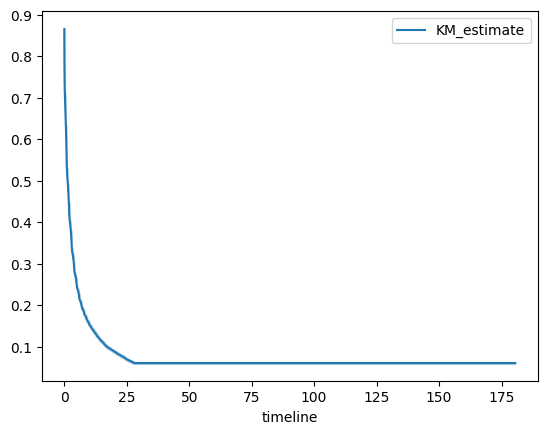

In [62]:
kmf = KaplanMeierFitter()
kmf.fit(durations=survival_data['duration'], event_observed=survival_data['event_observed'])

for day in [1, 7, 14, 30]:
    print(f"Survival probability at day {day}: {kmf.survival_function_at_times(day).values[0]:.4f}")

kmf.plot_survival_function()

Log-rank test p-value: 0.000000


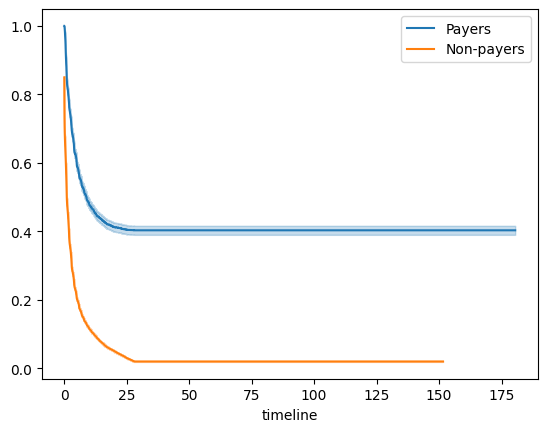

In [63]:
payers = survival_data[survival_data.is_payer_d30_any_revenue]
non_payers = survival_data[~survival_data.is_payer_d30_any_revenue]

kmf_payer, kmf_nonpayer = KaplanMeierFitter(), KaplanMeierFitter()
kmf_payer.fit(payers.duration, payers.event_observed, label='Payers')
kmf_nonpayer.fit(non_payers.duration, non_payers.event_observed, label='Non-payers')

ax = kmf_payer.plot_survival_function()
kmf_nonpayer.plot_survival_function(ax=ax)

result = logrank_test(payers.duration, non_payers.duration, payers.event_observed, non_payers.event_observed)
print(f"Log-rank test p-value: {result.p_value:.6f}")

Log-rank p-value (activated only, mature only): 0.000000


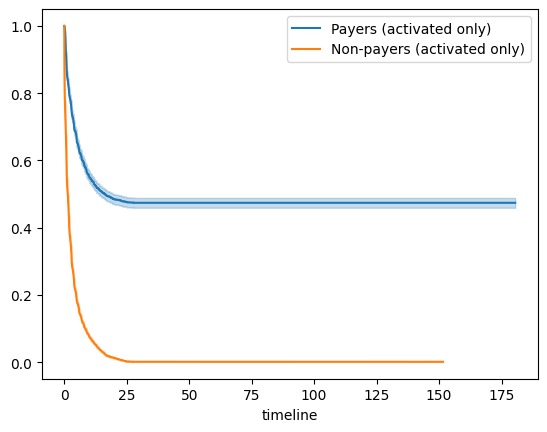

In [64]:
activated_users = t0plus_features[t0plus_features.user_id.isin(
    fact_events[fact_events.event_name.isin(['Message Sent','Message Received'])].user_id
)]
survival_mature = survival_data[survival_data.label_mature_d30]  # exclude immature this time
survival_activated = survival_mature[survival_mature.user_id.isin(activated_users.user_id)]

payers_act = survival_activated[survival_activated.is_payer_d30_any_revenue]
nonpayers_act = survival_activated[~survival_activated.is_payer_d30_any_revenue]

kmf_p2, kmf_np2 = KaplanMeierFitter(), KaplanMeierFitter()
kmf_p2.fit(payers_act.duration, payers_act.event_observed, label='Payers (activated only)')
kmf_np2.fit(nonpayers_act.duration, nonpayers_act.event_observed, label='Non-payers (activated only)')

ax = kmf_p2.plot_survival_function()
kmf_np2.plot_survival_function(ax=ax)

result2 = logrank_test(payers_act.duration, nonpayers_act.duration, payers_act.event_observed, nonpayers_act.event_observed)
print(f"Log-rank p-value (activated only, mature only): {result2.p_value:.6f}")

In [65]:
print(train_v2['ltv_d30'].describe())
print(f"\nExact zeros: {(train_v2.ltv_d30 == 0).mean():.4f}")
print(f"Non-zero mean (among payers only): {train_v2[train_v2.ltv_d30 > 0].ltv_d30.mean():.2f}")

count    29363.000000
mean        41.841774
std        158.215023
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1798.000000
Name: ltv_d30, dtype: float64

Exact zeros: 0.8909
Non-zero mean (among payers only): 383.58


In [66]:
lgb_train_ltv = lgb.Dataset(X_train_lgb, label=train_v2['ltv_d30'], categorical_feature=full_cat_cols)
lgb_val_ltv = lgb.Dataset(X_val_lgb, label=val_v2['ltv_d30'], categorical_feature=full_cat_cols, reference=lgb_train_ltv)

params_ltv = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.5,   # 1=Poisson-like, 2=Gamma-like; 1.5 is the standard middle ground for this shape
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 15,
    'verbose': -1,
}

model_ltv = lgb.train(
    params_ltv, lgb_train_ltv, num_boost_round=500,
    valid_sets=[lgb_val_ltv], valid_names=['val'],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(0)]
)

val_ltv_preds = model_ltv.predict(X_val_lgb)
print(f"Best iteration: {model_ltv.best_iteration}")
print(f"Mean actual LTV:    {val_v2.ltv_d30.mean():.2f}")
print(f"Mean predicted LTV: {val_ltv_preds.mean():.2f}")

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[66]	val's rmse: 161.067
Best iteration: 66
Mean actual LTV:    46.13
Mean predicted LTV: 48.32


In [67]:
# R-squared would be misleading here given the skew -- what matters is whether
# ranking by predicted LTV actually separates real high-value users from real low-value ones
val_ltv_check = val_v2.copy()
val_ltv_check['predicted_ltv'] = val_ltv_preds
val_ltv_check['decile'] = pd.qcut(val_ltv_check['predicted_ltv'], 10, labels=False, duplicates='drop')

print(val_ltv_check.groupby('decile').agg(
    n=('user_id', 'count'),
    avg_predicted=('predicted_ltv', 'mean'),
    avg_actual=('ltv_d30', 'mean')
).round(2).sort_index(ascending=False))

           n  avg_predicted  avg_actual
decile                                 
7        630          75.83       66.44
6        599          66.60       65.06
5        659          64.16       56.10
4        629          62.84       55.53
3        627          61.60       58.17
2        631          59.20       52.90
1        629          52.83       61.69
0       1888          13.43       15.31


In [68]:
# Same diagnostic instinct as Step 9's channel breakdown -- look at what's actually IN
# the inverted buckets before guessing why
for d in [1, 2, 3, 4]:
    subset = val_ltv_check[val_ltv_check.decile == d]
    print(f"\n--- Decile {d} (n={len(subset)}) ---")
    print(f"Payer rate: {subset.is_payer_d30_any_revenue.mean():.4f}")
    print(subset.channel.value_counts(normalize=True).round(3).head(3))


--- Decile 1 (n=629) ---
Payer rate: 0.1335
channel
YouTube Creators    0.308
Meta Ads            0.199
Google Ads          0.197
Name: proportion, dtype: float64

--- Decile 2 (n=631) ---
Payer rate: 0.1141
channel
Google Ads           0.309
Meta Ads             0.281
Organic App Store    0.189
Name: proportion, dtype: float64

--- Decile 3 (n=627) ---
Payer rate: 0.1180
channel
Organic App Store    0.396
Google Ads           0.273
Meta Ads             0.244
Name: proportion, dtype: float64

--- Decile 4 (n=629) ---
Payer rate: 0.1081
channel
Organic App Store    0.612
Google Ads           0.165
Meta Ads             0.161
Name: proportion, dtype: float64


In [69]:
def blend_scores(row):
    """
    Weight shifts from prior toward personal-model score as pre-message
    signal accumulates. never_activated_flag == 1 means zero signal exists
    at all -- lean almost entirely on the prior in that case.
    """
    if row['never_activated_flag'] == 1:
        signal_weight = 0.05  # essentially nothing to go on beyond the prior
    else:
        # more app opens + longer deliberate latency = more accumulated signal to trust
        signal_strength = min(row['n_app_opens_pre_message'] / 3, 1.0) * 0.5 + \
                           min(row['browse_to_chat_latency_minutes'] / 60, 1.0) * 0.5
        signal_weight = 0.20 + signal_strength * 0.60  # ranges roughly 0.20 -> 0.80

    return signal_weight

val_v2 = val_v2.copy()
val_v2['signal_weight'] = val_v2.apply(blend_scores, axis=1)
val_v2['model_score'] = val_probs_lgb  # from Step 9's LightGBM payer model
val_v2['prior_score'] = val_v2['channel_prior_payer_rate_any_revenue']

val_v2['blended_score'] = (val_v2['signal_weight'] * val_v2['model_score'] +
                            (1 - val_v2['signal_weight']) * val_v2['prior_score'])

print(val_v2[['signal_weight','model_score','prior_score','blended_score']].describe())

       signal_weight  model_score  prior_score  blended_score
count    6292.000000  6292.000000  6292.000000    6292.000000
mean        0.390745     0.385024     0.109153       0.235321
std         0.188328     0.188948     0.016039       0.099733
min         0.200000     0.016275     0.076500       0.064455
25%         0.309879     0.432027     0.096300       0.209132
50%         0.332984     0.480149     0.106100       0.233608
75%         0.356459     0.487041     0.115100       0.263469
max         0.800000     0.873949     0.151300       0.722179


In [70]:
print(f"Model alone:    ROC-AUC {roc_auc_score(y_val_lgb, val_v2.model_score):.4f}, PR-AUC {average_precision_score(y_val_lgb, val_v2.model_score):.4f}")
print(f"Prior alone:    ROC-AUC {roc_auc_score(y_val_lgb, val_v2.prior_score):.4f}, PR-AUC {average_precision_score(y_val_lgb, val_v2.prior_score):.4f}")
print(f"Blended:        ROC-AUC {roc_auc_score(y_val_lgb, val_v2.blended_score):.4f}, PR-AUC {average_precision_score(y_val_lgb, val_v2.blended_score):.4f}")

Model alone:    ROC-AUC 0.6335, PR-AUC 0.1574
Prior alone:    ROC-AUC 0.5453, PR-AUC 0.1082
Blended:        ROC-AUC 0.6253, PR-AUC 0.1485


In [71]:
import numpy as np

best_auc, best_params = 0, None
for opens_cap in [1, 2, 3, 5]:
    for latency_cap in [30, 60, 120, 240]:
        for max_weight in [0.7, 0.85, 0.95]:
            sw = np.where(
                val_v2['never_activated_flag'] == 1, 0.05,
                0.20 + (np.minimum(val_v2['n_app_opens_pre_message']/opens_cap, 1.0)*0.5 +
                        np.minimum(val_v2['browse_to_chat_latency_minutes']/latency_cap, 1.0)*0.5) * (max_weight - 0.20)
            )
            blend = sw * val_v2['model_score'] + (1-sw) * val_v2['prior_score']
            auc = roc_auc_score(y_val_lgb, blend)
            if auc > best_auc:
                best_auc, best_params = auc, (opens_cap, latency_cap, max_weight)

print(f"Best ROC-AUC: {best_auc:.4f} (model alone was 0.6335)")
print(f"Best params: opens_cap={best_params[0]}, latency_cap={best_params[1]}, max_weight={best_params[2]}")

Best ROC-AUC: 0.6323 (model alone was 0.6335)
Best params: opens_cap=1, latency_cap=240, max_weight=0.7


In [79]:
cox_features = ['browse_to_chat_latency_minutes', 'n_app_opens_pre_message',
                 'channel_prior_payer_rate_any_revenue', 'is_organic', 'signup_hour_of_day']

cox_data = train_v2.merge(
    survival_data[['user_id', 'duration', 'event_observed']], on='user_id'
)[['duration', 'event_observed'] + cox_features].copy()
cox_data['is_organic'] = cox_data['is_organic'].astype(int)

cph = CoxPHFitter()
cph.fit(cox_data, duration_col='duration', event_col='event_observed')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 29363 total observations, 2161 right-censored observations>
             duration col = 'duration'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 29363
number of events observed = 27202
   partial log-likelihood = -258212.35
         time fit was run = 2026-07-09 22:29:33 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
browse_to_chat_latency_minutes       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
n_app_opens_pre_message              -0.05      0.95      0.01           -0.07           -0.03                0.94                0.97
channel_prior_payer_rate_any_revenue -1.97      0.14      0.51           -2.97           -0.97                0.05                0.38
is_organic                            0.01      1.01      0.02           -0.03            0.04                0.97                1.04
signup_hour_of_day                   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                                      cmp to     z      p  -log2(p)
covariate                                                          
browse_to_chat_latency_minutes          0.00 -4.12 <0.005     14.68
n_app_opens_pre_message                 0.00 -6.13 <0.005     30.07
channel_prior_payer_rate_any_revenue    0.00 -3.88 <0.005     13.20
is_organic                              0.00  0.37   0.71      0.49
signup_hour_of_day                      0.00 -0.52   0.60      0.73
---
Concordance = 0.57
Partial AIC = 516434.70
log-likelihood ratio test = 131.36 on 5 df
-log2(p) of ll-ratio test = 86.08

In [74]:
import joblib

model_lgb.save_model('model_payer.txt')
model_ltv.save_model('model_ltv.txt')
joblib.dump(cph, 'model_retention_cox.pkl')
channel_priors.to_csv('channel_priors.csv')
joblib.dump(list(X_train_lgb.dtypes[X_train_lgb.dtypes == 'category'].index), 'categorical_cols.pkl')
joblib.dump({col: X_train_lgb[col].cat.categories.tolist() for col in full_cat_cols}, 'category_levels.pkl')

['category_levels.pkl']

In [75]:
import lightgbm as lgb
import pandas as pd
import numpy as np

class IraPreFirstMessageScorer:
    def __init__(self, model_dir='.'):
        self.model_payer = lgb.Booster(model_file=f'{model_dir}/model_payer.txt')
        self.model_ltv = lgb.Booster(model_file=f'{model_dir}/model_ltv.txt')
        self.cph = joblib.load(f'{model_dir}/model_retention_cox.pkl')
        self.channel_priors = pd.read_csv(f'{model_dir}/channel_priors.csv', index_col='channel')
        self.cat_cols = joblib.load(f'{model_dir}/categorical_cols.pkl')
        self.cat_levels = joblib.load(f'{model_dir}/category_levels.pkl')
        # tuned in Step 13
        self.OPENS_CAP, self.LATENCY_CAP, self.MAX_WEIGHT = 1, 240, 0.7

    def _prep_row(self, user):
        row = pd.DataFrame([user])
        for col in self.cat_cols:
            row[col] = pd.Categorical([user.get(col, 'undefined')], categories=self.cat_levels[col])
        return row

    def _signal_weight(self, user):
        if user.get('never_activated_flag', 1) == 1:
            return 0.05
        strength = (min(user.get('n_app_opens_pre_message', 0) / self.OPENS_CAP, 1.0) * 0.5 +
                    min(user.get('browse_to_chat_latency_minutes', 0) / self.LATENCY_CAP, 1.0) * 0.5)
        return 0.20 + strength * (self.MAX_WEIGHT - 0.20)

    def score(self, user: dict):
        row = self._prep_row(user)
        model_score = self.model_payer.predict(row)[0]
        prior_score = self.channel_priors.loc[user['channel'], 'payer_rate_any_revenue']
        weight = self._signal_weight(user)
        payer_probability = weight * model_score + (1 - weight) * prior_score

        predicted_ltv = float(self.model_ltv.predict(row)[0])

        cox_row = pd.DataFrame([{c: user.get(c, 0) for c in
            ['browse_to_chat_latency_minutes','n_app_opens_pre_message','never_activated_flag',
             'channel_prior_payer_rate_any_revenue','is_organic','signup_hour_of_day']}])
        surv_fn = self.cph.predict_survival_function(cox_row, times=[1, 7, 14, 30])

        return {
            'payer_probability': round(float(payer_probability), 4),
            'signal_weight_used': round(weight, 3),
            'predicted_ltv_d30_inr': round(predicted_ltv, 2),
            'retention_probability': {
                'day_1': round(float(surv_fn.iloc[0, 0]), 4),
                'day_7': round(float(surv_fn.iloc[1, 0]), 4),
                'day_14': round(float(surv_fn.iloc[2, 0]), 4),
                'day_30': round(float(surv_fn.iloc[3, 0]), 4),
            }
        }

In [76]:
import lightgbm as lgb
import pandas as pd
import numpy as np

class IraPreFirstMessageScorer:
    def __init__(self, model_dir='.'):
        self.model_payer = lgb.Booster(model_file=f'{model_dir}/model_payer.txt')
        self.model_ltv = lgb.Booster(model_file=f'{model_dir}/model_ltv.txt')
        self.cph = joblib.load(f'{model_dir}/model_retention_cox.pkl')
        self.channel_priors = pd.read_csv(f'{model_dir}/channel_priors.csv', index_col='channel')
        self.cat_cols = joblib.load(f'{model_dir}/categorical_cols.pkl')
        self.cat_levels = joblib.load(f'{model_dir}/category_levels.pkl')
        # tuned in Step 13
        self.OPENS_CAP, self.LATENCY_CAP, self.MAX_WEIGHT = 1, 240, 0.7

    def _prep_row(self, user):
        row = pd.DataFrame([user])
        for col in self.cat_cols:
            row[col] = pd.Categorical([user.get(col, 'undefined')], categories=self.cat_levels[col])
        return row

    def _signal_weight(self, user):
        if user.get('never_activated_flag', 1) == 1:
            return 0.05
        strength = (min(user.get('n_app_opens_pre_message', 0) / self.OPENS_CAP, 1.0) * 0.5 +
                    min(user.get('browse_to_chat_latency_minutes', 0) / self.LATENCY_CAP, 1.0) * 0.5)
        return 0.20 + strength * (self.MAX_WEIGHT - 0.20)

    def score(self, user: dict):
        row = self._prep_row(user)
        model_score = self.model_payer.predict(row)[0]
        prior_score = self.channel_priors.loc[user['channel'], 'payer_rate_any_revenue']
        weight = self._signal_weight(user)
        payer_probability = weight * model_score + (1 - weight) * prior_score

        predicted_ltv = float(self.model_ltv.predict(row)[0])

        cox_row = pd.DataFrame([{c: user.get(c, 0) for c in
            ['browse_to_chat_latency_minutes','n_app_opens_pre_message','never_activated_flag',
             'channel_prior_payer_rate_any_revenue','is_organic','signup_hour_of_day']}])
        surv_fn = self.cph.predict_survival_function(cox_row, times=[1, 7, 14, 30])

        return {
            'payer_probability': round(float(payer_probability), 4),
            'signal_weight_used': round(weight, 3),
            'predicted_ltv_d30_inr': round(predicted_ltv, 2),
            'retention_probability': {
                'day_1': round(float(surv_fn.iloc[0, 0]), 4),
                'day_7': round(float(surv_fn.iloc[1, 0]), 4),
                'day_14': round(float(surv_fn.iloc[2, 0]), 4),
                'day_30': round(float(surv_fn.iloc[3, 0]), 4),
            }
        }

In [83]:
try:
    cph.print_summary()
    print("\ncph IS fit correctly in memory.")
except Exception as e:
    print(f"cph is NOT fit: {e}")

<lifelines.CoxPHFitter: fitted with 29363 total observations, 2161 right-censored observations>
             duration col = 'duration'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 29363
number of events observed = 27202
   partial log-likelihood = -258212.35
         time fit was run = 2026-07-09 22:29:33 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
browse_to_chat_latency_minutes       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
n_app_opens_pre_message              -0.05      0.95      0.01           -0.07           -0.03                0.94                0.97
channel_prior_payer_rate_any_revenue -1.97      0.14      0.51           -2.97           -0.97                0.05                0.38
is_organic                            0.01      1.01      0.02           -0.03            0.04                0.97                1.04
signup_hour_of_day                   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                                      cmp to     z      p  -log2(p)
covariate                                                          
browse_to_chat_latency_minutes          0.00 -4.12 <0.005     14.68
n_app_opens_pre_message                 0.00 -6.13 <0.005     30.07
channel_prior_payer_rate_any_revenue    0.00 -3.88 <0.005     13.20
is_organic                              0.00  0.37   0.71      0.49
signup_hour_of_day                      0.00 -0.52   0.60      0.73
---
Concordance = 0.57
Partial AIC = 516434.70
log-likelihood ratio test = 131.36 on 5 df
-log2(p) of ll-ratio test = 86.08


cph IS fit correctly in memory.


In [84]:
import joblib
joblib.dump(cph, 'model_retention_cox.pkl')

scorer = IraPreFirstMessageScorer()
print("Brand-new signup, zero signal:")
print(scorer.score(brand_new_user))
print("\nSame profile, but browsed 45 min / 2 opens before first message:")
print(scorer.score(engaged_user))

Brand-new signup, zero signal:
{'payer_probability': 0.1016, 'signal_weight_used': 0.05, 'predicted_ltv_d30_inr': 0.06, 'retention_probability': {'day_1': 0.5294, 'day_7': 0.1989, 'day_14': 0.1253, 'day_30': 0.0634}}

Same profile, but browsed 45 min / 2 opens before first message:
{'payer_probability': 0.3018, 'signal_weight_used': 0.497, 'predicted_ltv_d30_inr': 71.08, 'retention_probability': {'day_1': 0.5639, 'day_7': 0.2335, 'day_14': 0.1539, 'day_30': 0.0834}}
